In [2]:
import pandas as pd
import numpy as np
import plotly.express as px

print("Environment working")

Environment working


In [9]:
import os
print(os.getcwd())

C:\Users\black\OneDrive\Documents\Job search\Python\energy-forecast


In [13]:
df = pd.read_csv('data/demanddata_2024.csv')
#print(df.shape)
#print(df.head())
#print(df.dtypes)


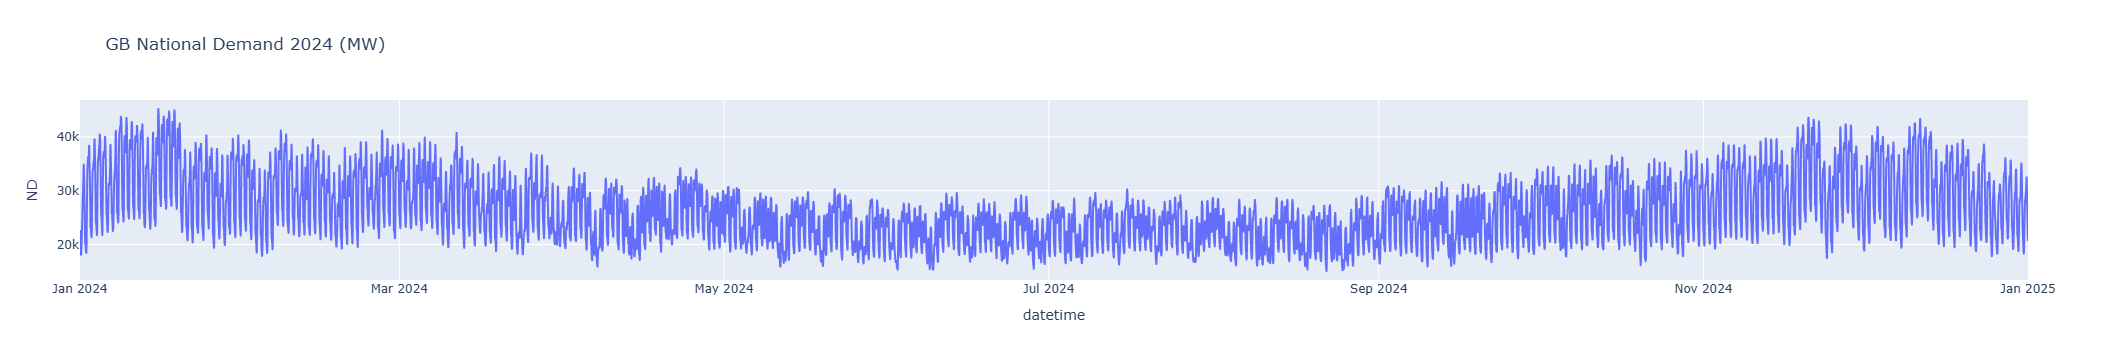

In [23]:
# Parse the date and create a proper datetime index
df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], format='%d-%b-%Y')

# Create a single datetime column combining date and settlement period
# Each period is 30 minutes, period 1 starts at 00:00
df['datetime'] = df['SETTLEMENT_DATE'] + pd.to_timedelta((df['SETTLEMENT_PERIOD'] - 1) * 30, unit='m')

df = df.set_index('datetime')
df = df.sort_index()

# Quick plot of National Demand
import plotly.express as px

fig = px.line(df, y='ND', title='GB National Demand 2024 (MW)')
fig.show()

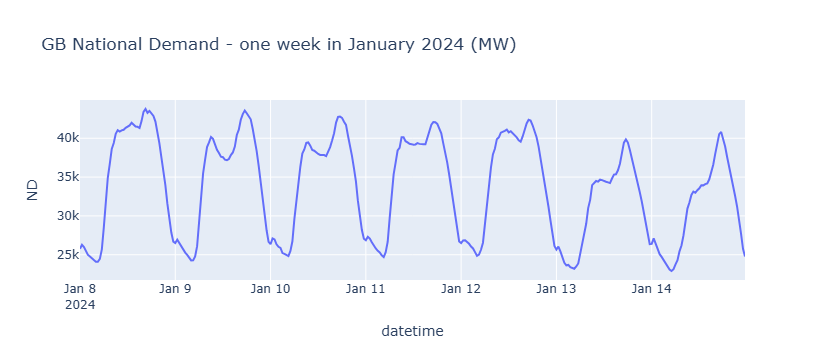

In [26]:
# Plot just one week to see the daily shape clearly
#print(df.head())
one_week = df['2024-01-08':'2024-01-14']

fig = px.line(one_week, y='ND', title='GB National Demand - one week in January 2024 (MW)')
fig.show();

In [27]:
df['hour'] = df.index.hour
daily_average = df.groupby('hour').ND.mean()

fig = px.ine(hourly_average, y='ND', title='Hourly average over 2024')
fig.show()




AttributeError: module 'plotly.express' has no attribute 'ine'